In [1]:
# import standard python libraries
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 96
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v4/supp13'

if not os.path.exists(savedir):
    os.mkdir(savedir)

In [3]:
expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')

phases = ['AAVS1_P3', 'NFE2_P3']
dists = [25000, 50000, 100000, 200000]

type_use= 'erythroid_tf_acrs_all'
peak_use = 'enhancernotpromoternotctcf'

cooler_path = '/mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/'
cooler_names = [os.path.join(cooler_path, f"{p}_microc.50.mcool::resolutions/5000") for p in phases]

phase_clrs = [cooler.Cooler(c) for c in cooler_names]
exps = [os.path.join(expdir, f"P_s_{phase}_5000bp_hg38arms.tsv") for phase in phases]

In [4]:
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
    # create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

    # select only those chromosomes available in cooler
hg38_arms = hg38_arms[hg38_arms.chrom.isin(phase_clrs[0].chromnames)].reset_index(drop=True)
hg38_arms = hg38_arms[~hg38_arms["chrom"].isin(['chrY','chrM'])]

In [5]:
subdir = 'nfe2_only_tf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')
import ast
list_cols = ['crosser_loop_scores_P2', 'crosser_loop_classes_P2', 'crosser_loop_coords_P2',
            'ss_loop_scores_P2', 'ss_loop_classes_P2', 'ss_loop_coords_P2',
            'crosser_loop_scores_P1', 'crosser_loop_classes_P1', 'crosser_loop_coords_P1',
            'ss_loop_scores_P1', 'ss_loop_classes_P1', 'ss_loop_coords_P1']
track[list_cols] = track[list_cols].applymap(ast.literal_eval)


In [6]:
track.columns

Index(['chr', 'coord', 'perturbation_name', 'triangle_score_P1',
       'crosser_loop_scores_P1', 'crosser_loop_classes_P1',
       'crosser_loop_coords_P1', 'ss_loop_scores_P1', 'ss_loop_classes_P1',
       'ss_loop_coords_P1', 'agg_crosser_score_P1', 'agg_ss_score_P1',
       'mean_crosser_score_P1', 'mean_ss_score_P1', 'triangle_score_P2',
       'crosser_loop_scores_P2', 'crosser_loop_classes_P2',
       'crosser_loop_coords_P2', 'ss_loop_scores_P2', 'ss_loop_classes_P2',
       'ss_loop_coords_P2', 'agg_crosser_score_P2', 'agg_ss_score_P2',
       'mean_crosser_score_P2', 'mean_ss_score_P2', 'quant', 'chr_diff',
       'quant_diff'],
      dtype='object')

In [7]:
track_base = subdir.split('.')[0]
print(track_base)

nfe2_only_tf_100kb_merge10


In [8]:
track[track['quant_diff'].isna()]

,chr,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,ss_loop_scores_P2,ss_loop_classes_P2,ss_loop_coords_P2,agg_crosser_score_P2,agg_ss_score_P2,mean_crosser_score_P2,mean_ss_score_P2,quant,chr_diff,quant_diff
28,chr1,61196773.0,NFE2,1.273981,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,2,NaN,NaN
108,chr2,26353053.0,NFE2,1.163222,[2.491468850402822],[E-P],"[(26346500.5, 26412500.5)]",[],[],[],...,[],[],[],1.958698,0.000000,1.958698,NaN,1,NaN,NaN
132,chr2,96148707.5,NFE2,1.262541,"[5.370974314499141, 2.2141799839706717]","[E-P, P-P]","[(96139500.5, 96174500.5), (96145500.5, 962075...",[],[],[],...,[],[],[],6.009688,0.000000,3.004844,NaN,1,NaN,NaN
185,chr3,53236351.5,NFE2,1.095233,[2.4653103618578207],[E-CTCF],"[(53220500.5, 53270500.5)]",[None],[E-P],"[(53258500.5, 53267500.5)]",...,[None],[E-P],"[(53258500.5, 53267500.5)]",1.994631,NaN,1.994631,NaN,1,NaN,NaN
206,chr3,129050482.5,NFE2,1.693420,"[2.1705908531887896, 3.628121883531665, 3.0285...","[E-CTCF, CTCF-Null, CTCF-Null, P-CTCF, E-E]","[(128970500.5, 129052500.5), (128970500.5, 129...","[None, 1.486959606720306]","[E-E, E-P]","[(129055000.5, 129085000.5), (129056500.5, 129...",...,"[None, 1.577487962021729]","[E-E, E-P]","[(129055000.5, 129085000.5), (129056500.5, 129...",13.878040,NaN,2.775608,1.577488,3,NaN,NaN
269,chr5,14865819.0,NFE2,1.082215,[1.9706454167156429],[P-Null],"[(14810500.5, 14871500.5)]",[],[],[],...,[],[],[],1.762452,0.000000,1.762452,NaN,1,NaN,NaN
317,chr6,15091594.5,NFE2,1.529982,[],[],[],[],[],[],...,[],[],[],0.000000,0.000000,NaN,NaN,2,NaN,NaN
332,chr6,42039718.5,NFE2,0.505402,[],[],[],"[3.8390523652243913, None, 1.9302558840962971]","[E-P, E-E, E-CTCF]","[(41940500.5, 42016500.5), (42018500.5, 420285...",...,"[4.160470490562591, None, 2.0601721446916703]","[E-P, E-E, E-CTCF]","[(41940500.5, 42016500.5), (42018500.5, 420285...",0.000000,NaN,NaN,3.110321,0,NaN,NaN
336,chr6,43811273.5,NFE2,1.263945,"[2.3849680401691984, 2.0031939140581194, 2.772...","[E-E, E-E, E-P, E-P]","[(43723500.5, 43839500.5), (43724500.5, 438175...","[2.2162084990246598, 2.726146173120508, 1.6367...","[E-CTCF, E-P, E-E]","[(43724500.5, 43758500.5), (43724500.5, 437715...",...,"[1.988627452268112, 2.616676131842253, 1.42095...","[E-CTCF, E-P, E-E]","[(43724500.5, 43758500.5), (43724500.5, 437715...",9.732462,6.026258,2.433116,2.008753,2,NaN,NaN
355,chr6,139434052.5,NFE2,1.342798,"[2.7016982968414385, 4.342604306224092, 3.9804...","[E-P, E-P, E-P, P-P, E-P, E-P]","[(139374500.5, 139498500.5), (139374500.5, 139...","[2.9004355269911075, 3.5535772040274747, 2.324...","[E-E, E-E, E-E, E-P, E-E]","[(139446500.5, 139518500.5), (139446500.5, 139...",...,"[3.470059064326211, 3.462005036898205, 2.26602...","[E-E, E-E, E-E, E-P, E-E]","[(139446500.5, 139518500.5), (139446500.5, 139...",19.954452,12.666961,3.325742,2.533392,2,NaN,NaN


In [9]:
# 100 kb 

cooler_path = '/mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/'
cooler_names = [os.path.join(cooler_path, f"{p}_microc.50.mcool::resolutions/5000") for p in phases]

phase_clrs = [cooler.Cooler(c) for c in cooler_names]
exps = [os.path.join(expdir, f"P_s_{phase}_5000bp_hg38arms.tsv") for phase in phases]

pup_mats_all = [None]*2

track_sub = track[track['quant_diff'].isin([2, 3])]
track_sub['chrom'] = track_sub['chr']
track_sub['start'] = track_sub['coord']-100
track_sub['end'] = track_sub['coord']+100
    
for p in [0, 1]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    
    pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
    fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2)

    
    #fg.savefig(os.path.join(savedir, f"{track_base}_p{p+1}_MMs.svg"))
    fg
    
    pup_mats_all[p] = pup


KeyboardInterrupt



In [75]:
pup_diff = np.log2(pup_mats_all[1]['data'][0]) - np.log2(pup_mats_all[0]['data'][0])

from matplotlib import colors

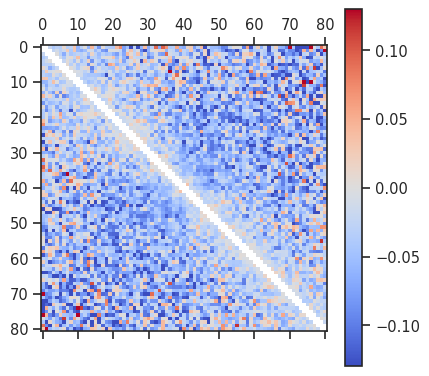

In [77]:
plt.matshow(pup_diff, vmin=-0.13, vmax=0.13, cmap='coolwarm')
plt.colorbar()
plt.savefig(os.path.join(savedir, "5kb_diff_map.svg"))

INFO:coolpuppy:('chr5_p', 'chr5_p'): 4
INFO:coolpuppy:('chr4_p', 'chr4_p'): 1
INFO:coolpuppy:('chr8_p', 'chr8_p'): 2
INFO:coolpuppy:('chr6_p', 'chr6_p'): 8
INFO:coolpuppy:('chr7_p', 'chr7_p'): 10
INFO:coolpuppy:('chr2_p', 'chr2_p'): 14
INFO:coolpuppy:('chr3_p', 'chr3_p'): 6
INFO:coolpuppy:('chr7_q', 'chr7_q'): 10
INFO:coolpuppy:('chr8_q', 'chr8_q'): 8
INFO:coolpuppy:('chr1_p', 'chr1_p'): 24
INFO:coolpuppy:('chr10_p', 'chr10_p'): 7
INFO:coolpuppy:('chr9_p', 'chr9_p'): 6
INFO:coolpuppy:('chr6_q', 'chr6_q'): 11
INFO:coolpuppy:('chr5_q', 'chr5_q'): 15
INFO:coolpuppy:('chr4_q', 'chr4_q'): 9
INFO:coolpuppy:('chr12_p', 'chr12_p'): 2
INFO:coolpuppy:('chr11_p', 'chr11_p'): 3
INFO:coolpuppy:('chr9_q', 'chr9_q'): 6
INFO:coolpuppy:('chr3_q', 'chr3_q'): 15
INFO:coolpuppy:('chr10_q', 'chr10_q'): 11
INFO:coolpuppy:('chr16_p', 'chr16_p'): 1
INFO:coolpuppy:('chr13_q', 'chr13_q'): 7
INFO:coolpuppy:('chr1_q', 'chr1_q'): 15
INFO:coolpuppy:('chr2_q', 'chr2_q'): 14
INFO:coolpuppy:('chr16_q', 'chr16_q'): 9
I

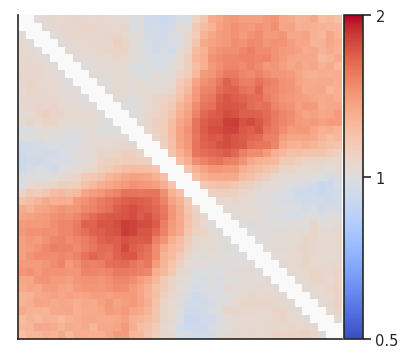

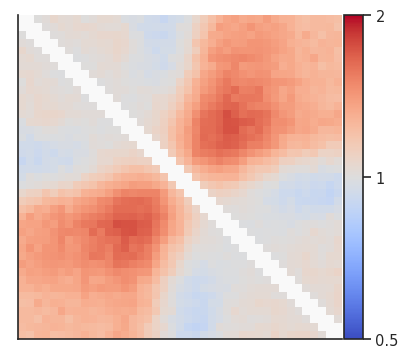

In [78]:
expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')

phases = ['AAVS1_P3', 'NFE2_P3']

cooler_path = '/mnt/md1/varshini/sankaran_tfko_microc/full_merged_files/'
cooler_names = [os.path.join(cooler_path, f"{p}_microc.50.mcool::resolutions/10000") for p in phases]

phase_clrs = [cooler.Cooler(c) for c in cooler_names]
exps = [os.path.join(expdir, f"P_s_{phase}_10000bp_hg38arms.tsv") for phase in phases]

# 100 kb 
pup_mats_all = [None]*2

track_sub = track[track['quant_diff'].isin([2, 3])]
track_sub['chrom'] = track_sub['chr']
track_sub['start'] = track_sub['coord']-100
track_sub['end'] = track_sub['coord']+100
    
for p in [0, 1]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    
    pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
    fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2)

    
    #fg.savefig(os.path.join(savedir, f"{track_base}_p{p+1}_MMs.svg"))
    fg
    
    pup_mats_all[p] = pup

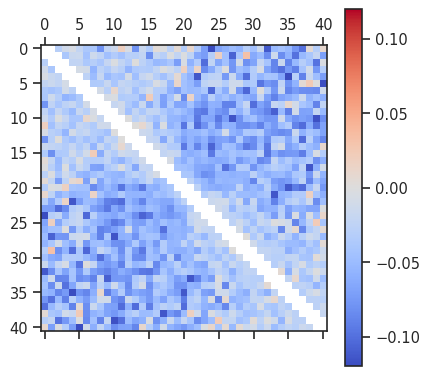

In [79]:
pup_diff = np.log2(pup_mats_all[1]['data'][0]) - np.log2(pup_mats_all[0]['data'][0])
plt.matshow(pup_diff, cmap='coolwarm', vmin=-0.12, vmax=0.12)
plt.colorbar()
plt.savefig(os.path.join(savedir, "10kb_diff_map.svg"))

In [ ]:
# now make the STAG2 style diagonal plot

In [ ]:
# ortho stripe
f, ax = plt.subplots()
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v4/supp13"

if not os.path.exists(savedir):
    os.mkdir(savedir)
for i in [0, 1]:
    snip1 = pup_mats_all[i]
    snip = snip1['data'][0]
    n = snip.shape[0]

    mid = n // 2

    # compute valid range lengths
    steps_up = mid + 1
    steps_right = n - mid
    L = min(steps_up, steps_right)

    # equal-length indices for the 45 anti-diagonal (upper half)
    rows = np.arange(mid, mid - L, -1)
    cols = np.arange(mid, mid + L)
    #plt.matshow(np.zeros([n,n]))
    #plt.scatter(rows[:4], cols[:4], cmap='Blues')
    ortho_stripe = snip[rows, cols]
    max_ortho_ind = np.nanargmax(ortho_stripe)
    ax.plot(ortho_stripe, label=phases[i])
    print(max_ortho_ind)
plt.legend()
#plt.yscale('log')
plt.xlabel('Distance from diagonal (5kb bins)')
plt.ylabel('Expected-normalized intensity')
plt.savefig(os.path.join(savedir, "nfe2_ortho_stripe_all.svg"))
plt.show()

In [ ]:
track_all = track.copy()
track_all['chrom'] = track_all['chr']
track_all['start'] = track_all['coord']-100
track_all['end'] = track_all['coord']+100

for p in [0, 1]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')
    
    pup = coolpup.pileup(clr, track_all, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
    fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=1.5)

    fg.savefig(os.path.join(savedir, f"{track_base}_p{p+1}_allTF.svg"))

In [ ]:
# now explode on loops and pileup on CTCF-CTCF loops vs. exclusive ?? E-P loops?

In [10]:
loop_basedir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors'
lc = 'merged_calls_125kb_q0.01_classes_new.txt'
excl = 'merged_calls_125kb_q0.01_classes_excl.txt'
ls = 'nfe2_oe_scores_2000bp.tsv'

loop_classes = pd.read_csv(os.path.join(loop_basedir, lc), sep='\t').rename({'seqnames1':'chrom1','seqnames2':'chr2', 'pair':'class'}, axis=1)
loop_classes['coord1']=loop_classes[['start1','end1']].mean(axis=1)
loop_classes['coord2']=loop_classes[['start2','end2']].mean(axis=1)


excl_loop_classes = pd.read_csv(os.path.join(loop_basedir, excl), sep='\t').rename({'seqnames1':'chrom1','seqnames2':'chr2', 'pair':'class'}, axis=1).drop('NA.',axis=1)
excl_loop_classes['coord1']=excl_loop_classes[['start1','end1']].mean(axis=1)
excl_loop_classes['coord2']=excl_loop_classes[['start2','end2']].mean(axis=1)


loops_oe = pd.read_csv(os.path.join(loop_basedir, ls), sep='\t', names=['chr1','start1','end1','chr2','start2','end2','aavs1','nfe2'])

loop_class_strengths = loops_oe.merge(loop_classes, how='inner', on=['start1','end1','chr2','start2','end2'])
loop_class_strengths_excl = loops_oe.merge(excl_loop_classes, how='inner', on=['start1','end1','chr2','start2','end2'])

In [11]:
exploded = track.explode(['crosser_loop_scores_P2','crosser_loop_scores_P1', 'crosser_loop_coords_P2', 'crosser_loop_classes_P2']).dropna(subset='crosser_loop_coords_P2')

exploded['start1'] = exploded['crosser_loop_coords_P2'].apply(lambda x: int(np.floor(x[0]-100)))
exploded['end1'] = exploded['crosser_loop_coords_P2'].apply(lambda x: int(np.floor(x[0]+100)))
exploded['start2'] = exploded['crosser_loop_coords_P2'].apply(lambda x: int(np.floor(x[1]-100)))
exploded['end2'] = exploded['crosser_loop_coords_P2'].apply(lambda x: int(np.floor(x[1]+100)))
exploded['chrom2'] = exploded['chr']
exploded['coord1'] = exploded['crosser_loop_coords_P2'].apply(lambda x: x[0])
exploded['coord2'] = exploded['crosser_loop_coords_P2'].apply(lambda x: x[1])
exploded['distance'] = exploded['coord2'] - exploded['coord1']
exploded.rename({'chr':'chrom1'}, inplace=True, axis=1)

In [12]:
exploded

,chrom1,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,chr_diff,quant_diff,start1,end1,start2,end2,chrom2,coord1,coord2,distance
0,chr1,6317423.0,NFE2,1.424136,2.408679,"[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,chr1,2.0,6236400,6236600,6393400,6393600,chr1,6236500.5,6393500.5,157000.0
0,chr1,6317423.0,NFE2,1.424136,2.634773,"[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,chr1,2.0,6238400,6238600,6343400,6343600,chr1,6238500.5,6343500.5,105000.0
0,chr1,6317423.0,NFE2,1.424136,6.097739,"[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,chr1,2.0,6247400,6247600,6343400,6343600,chr1,6247500.5,6343500.5,96000.0
0,chr1,6317423.0,NFE2,1.424136,2.961282,"[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,chr1,2.0,6247400,6247600,6395400,6395600,chr1,6247500.5,6395500.5,148000.0
0,chr1,6317423.0,NFE2,1.424136,4.88619,"[P-P, P-CTCF, P-CTCF, P-P, P-CTCF]","[(6236500.5, 6393500.5), (6238500.5, 6343500.5...","[1.355843235772496, 5.671889825626111, 2.71241...","[Null-Null, CTCF-CTCF, P-CTCF, P-P, P-CTCF, P-...","[(6249500.5, 6280500.5), (6347500.5, 6404500.5...",...,chr1,2.0,6247400,6247600,6404400,6404600,chr1,6247500.5,6404500.5,157000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,chrX,53374574.5,NFE2,1.912914,6.104667,"[E-Null, CTCF-CTCF, P-CTCF, P-CTCF]","[(53289000.5, 53441000.5), (53315500.5, 534455...",[None],[P-P],"[(53424500.5, 53433500.5)]",...,chrX,3.0,53316400,53316600,53436400,53436600,chrX,53316500.5,53436500.5,120000.0
872,chrX,119427490.0,NFE2,1.074473,1.910014,"[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2557127056371773, 2.1099793952016794, 1.920...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",...,chrX,1.0,119399400,119399600,119468400,119468600,chrX,119399500.5,119468500.5,69000.0
872,chrX,119427490.0,NFE2,1.074473,2.006176,"[P-P, CTCF-Null]","[(119399500.5, 119468500.5), (119417500.5, 119...","[1.2557127056371773, 2.1099793952016794, 1.920...","[E-P, P-CTCF, CTCF-Null]","[(119469500.5, 119482500.5), (119470500.5, 119...",...,chrX,1.0,119417400,119417600,119512400,119512600,chrX,119417500.5,119512500.5,95000.0
874,chrX,125399069.5,NFE2,1.486328,2.016216,"[E-Null, Null-Null]","[(125337500.5, 125402500.5), (125379000.5, 125...",[],[],[],...,chrX,2.0,125337400,125337600,125402400,125402600,chrX,125337500.5,125402500.5,65000.0


In [13]:
exploded_merged = pd.merge(exploded,loop_class_strengths,on=['chrom1','coord1','coord2'],
                           how="inner", suffixes=('','_lc'))

In [14]:
exploded_merged.columns

Index(['chrom1', 'coord', 'perturbation_name', 'triangle_score_P1',
       'crosser_loop_scores_P1', 'crosser_loop_classes_P1',
       'crosser_loop_coords_P1', 'ss_loop_scores_P1', 'ss_loop_classes_P1',
       'ss_loop_coords_P1', 'agg_crosser_score_P1', 'agg_ss_score_P1',
       'mean_crosser_score_P1', 'mean_ss_score_P1', 'triangle_score_P2',
       'crosser_loop_scores_P2', 'crosser_loop_classes_P2',
       'crosser_loop_coords_P2', 'ss_loop_scores_P2', 'ss_loop_classes_P2',
       'ss_loop_coords_P2', 'agg_crosser_score_P2', 'agg_ss_score_P2',
       'mean_crosser_score_P2', 'mean_ss_score_P2', 'quant', 'chr_diff',
       'quant_diff', 'start1', 'end1', 'start2', 'end2', 'chrom2', 'coord1',
       'coord2', 'distance', 'chr1', 'start1_lc', 'end1_lc', 'chr2',
       'start2_lc', 'end2_lc', 'aavs1', 'nfe2', 'annotation1', 'annotation2',
       'class'],
      dtype='object')

In [15]:
exploded_merged.columns

Index(['chrom1', 'coord', 'perturbation_name', 'triangle_score_P1',
       'crosser_loop_scores_P1', 'crosser_loop_classes_P1',
       'crosser_loop_coords_P1', 'ss_loop_scores_P1', 'ss_loop_classes_P1',
       'ss_loop_coords_P1', 'agg_crosser_score_P1', 'agg_ss_score_P1',
       'mean_crosser_score_P1', 'mean_ss_score_P1', 'triangle_score_P2',
       'crosser_loop_scores_P2', 'crosser_loop_classes_P2',
       'crosser_loop_coords_P2', 'ss_loop_scores_P2', 'ss_loop_classes_P2',
       'ss_loop_coords_P2', 'agg_crosser_score_P2', 'agg_ss_score_P2',
       'mean_crosser_score_P2', 'mean_ss_score_P2', 'quant', 'chr_diff',
       'quant_diff', 'start1', 'end1', 'start2', 'end2', 'chrom2', 'coord1',
       'coord2', 'distance', 'chr1', 'start1_lc', 'end1_lc', 'chr2',
       'start2_lc', 'end2_lc', 'aavs1', 'nfe2', 'annotation1', 'annotation2',
       'class'],
      dtype='object')

In [16]:
exploded_merged['loop_fc'] = exploded_merged['crosser_loop_scores_P2']/exploded_merged['crosser_loop_scores_P1']
exploded_merged['triangle_fc'] = exploded_merged['triangle_score_P2']/exploded_merged['triangle_score_P1']
exploded_merged = exploded_merged[(exploded_merged['quant_diff']==2) | (exploded_merged['quant_diff']==3)]

In [17]:
CTCF = ['E-CTCF','P-CTCF', 'CTCF-CTCF', ]
cc = exploded_merged[exploded_merged['crosser_loop_classes_P2'].isin(CTCF)]

In [18]:
cc['distance'] = cc['coord2'] - cc['coord1']


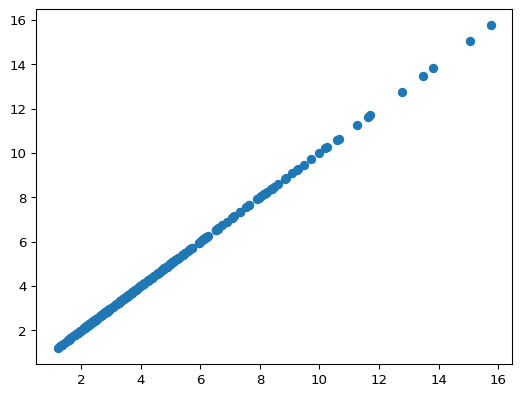

In [19]:
plt.scatter(cc['nfe2'], cc['crosser_loop_scores_P2'])

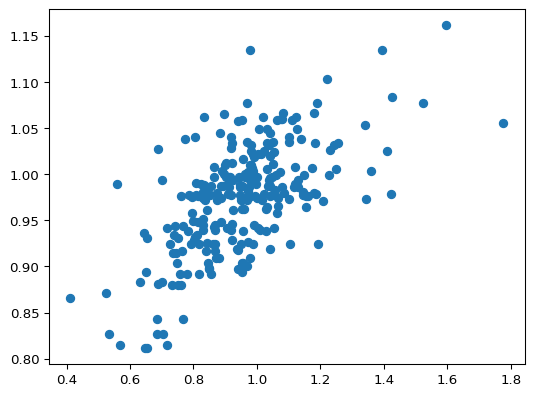

In [20]:
CRE = ['E-E','E-P','P-P']
cre = exploded_merged[exploded_merged['crosser_loop_classes_P2'].isin(CRE)]
plt.scatter(cc['loop_fc'], cc['triangle_fc'])

<AxesSubplot:xlabel='distance', ylabel='Count'>

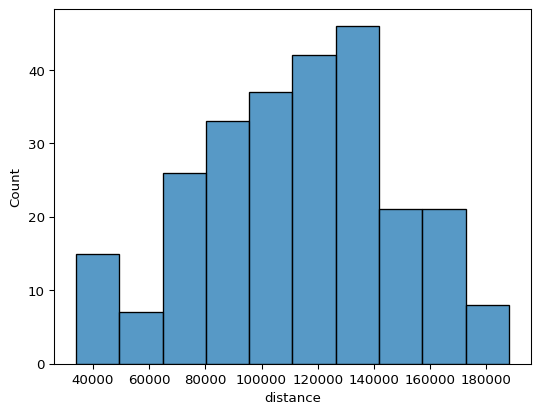

In [21]:
counts, bin_edges = np.histogram(cc['distance'], bins=10)
sns.histplot(cc['distance'], bins=10)

In [22]:
exploded_excl = pd.merge(loop_class_strengths_excl,exploded,on=['chrom1','coord1','coord2'],
                           how="outer", suffixes=('','_lc'), indicator=True)
exploded_excl = exploded_excl[exploded_excl['_merge']=='left_only']
exploded_excl['distance'] = exploded_excl['start2'] - exploded_excl['start1']

In [23]:
exploded_excl['loop_fc'] = exploded_excl['nfe2']/exploded_excl['aavs1']


In [24]:
cc2 = exploded_excl[exploded_excl['class'].isin(CTCF)]
cre2 = exploded_excl[exploded_excl['class'].isin(CRE)]


In [25]:
cc2

,chr1,start1,end1,chr2,start2,end2,aavs1,nfe2,chrom1,width1,...,chr_diff,quant_diff,start1_lc,end1_lc,start2_lc,end2_lc,chrom2,distance,_merge,loop_fc
0,chr1,868501.0,873500.0,chr1,972501.0,977500.0,1.979449,1.771716,chr1,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104000.0,left_only,0.895055
1,chr1,902501.0,907500.0,chr1,974501.0,979500.0,3.361771,3.340515,chr1,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72000.0,left_only,0.993677
2,chr1,903001.0,908000.0,chr1,936001.0,941000.0,2.114132,2.400818,chr1,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33000.0,left_only,1.135605
3,chr1,903001.0,908000.0,chr1,959001.0,964000.0,2.093094,1.927533,chr1,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56000.0,left_only,0.920902
4,chr1,904001.0,909000.0,chr1,921001.0,926000.0,1.266917,1.260933,chr1,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17000.0,left_only,0.995276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32300,chrX,154409001.0,154414000.0,chrX,154532001.0,154537000.0,6.983077,6.096496,chrX,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123000.0,left_only,0.873039
32305,chrX,154470001.0,154475000.0,chrX,154533001.0,154538000.0,2.814773,2.331604,chrX,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63000.0,left_only,0.828345
32310,chrX,154774001.0,154779000.0,chrX,154838001.0,154843000.0,2.629822,2.431024,chrX,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64000.0,left_only,0.924406
32315,chrX,155090501.0,155095500.0,chrX,155818501.0,155823500.0,10.621848,12.699626,chrX,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,728000.0,left_only,1.195614


In [26]:
loops_dist = pd.DataFrame(columns = cc.columns)
count_freq = (int(np.round(c)) for c in counts/sum(counts)*1000)

for i, count in enumerate(count_freq):
    print(i, count)
    try:
        loops_sub = cc2[(cc2['distance'] > bin_edges[i]) &
                                           (cc2['distance'] < bin_edges[i+1])].sample(count, random_state=1)
    except:
        loops_sub = cc2[(cc2['distance'] > bin_edges[i]) &
                                           (cc2['distance'] < bin_edges[i+1])]
    loops_dist = pd.concat([loops_dist, loops_sub], axis=0)
    

0 59
1 27
2 102
3 129
4 145
5 164
6 180
7 82
8 82
9 31


<AxesSubplot:xlabel='distance', ylabel='Count'>

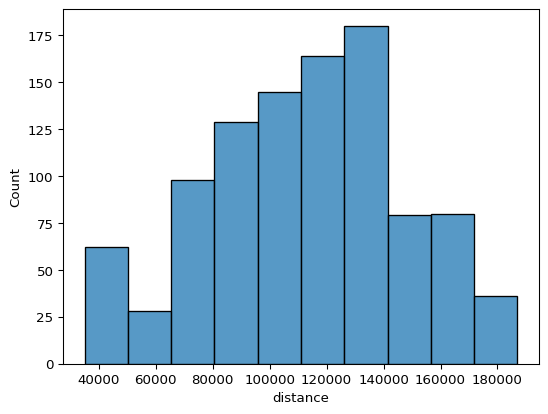

In [27]:
sns.histplot(loops_dist['distance'], bins=10)

In [28]:
from scipy.stats import mannwhitneyu

In [29]:
cc2.columns

Index(['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'aavs1', 'nfe2',
       'chrom1', 'width1', 'strand1', 'width2', 'strand2',
       'anchor1_annotation', 'anchor2_annotation', 'class', 'coord1', 'coord2',
       'coord', 'perturbation_name', 'triangle_score_P1',
       'crosser_loop_scores_P1', 'crosser_loop_classes_P1',
       'crosser_loop_coords_P1', 'ss_loop_scores_P1', 'ss_loop_classes_P1',
       'ss_loop_coords_P1', 'agg_crosser_score_P1', 'agg_ss_score_P1',
       'mean_crosser_score_P1', 'mean_ss_score_P1', 'triangle_score_P2',
       'crosser_loop_scores_P2', 'crosser_loop_classes_P2',
       'crosser_loop_coords_P2', 'ss_loop_scores_P2', 'ss_loop_classes_P2',
       'ss_loop_coords_P2', 'agg_crosser_score_P2', 'agg_ss_score_P2',
       'mean_crosser_score_P2', 'mean_ss_score_P2', 'quant', 'chr_diff',
       'quant_diff', 'start1_lc', 'end1_lc', 'start2_lc', 'end2_lc', 'chrom2',
       'distance', '_merge', 'loop_fc'],
      dtype='object')

In [30]:
mannwhitneyu(loops_dist['loop_fc'].fillna(np.nan).dropna(), cc['loop_fc'].fillna(np.nan).dropna())

MannwhitneyuResult(statistic=135778.0, pvalue=0.013324193697371978)

In [31]:
tidy_df_cc = pd.DataFrame()
tidy_df_cc['loop_fc'] = cc['loop_fc'].values
tidy_df_cc['MM Status'] = 'Matchmaker'

tidy_df_cc2 = pd.DataFrame()
tidy_df_cc2['loop_fc'] = loops_dist['loop_fc'].values

tidy_df_cc2['MM Status'] = 'NotMatch'

tidy_df = pd.concat([tidy_df_cc, tidy_df_cc2], axis=0).reset_index(drop=True).dropna()

tidy_df['loop_fc'] = np.log2(pd.to_numeric(tidy_df['loop_fc'], errors='coerce'))

In [ ]:
tidy_df.groupby('MM Status').agg('size')

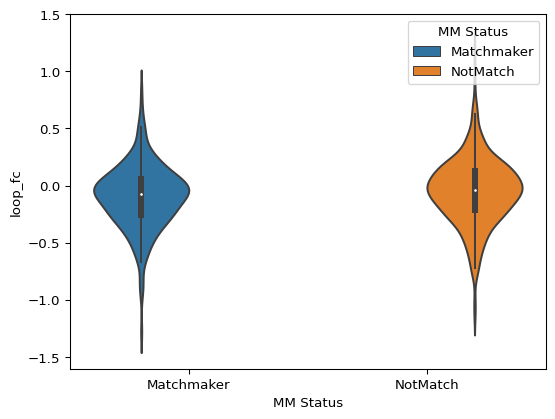

In [32]:

sns.violinplot(
    data=tidy_df,
    x='MM Status',
    y='loop_fc',
    hue='MM Status',
)

plt.savefig(os.path.join(savedir, "cc_loop_comp_nfe2.svg"))

/home/varshini/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


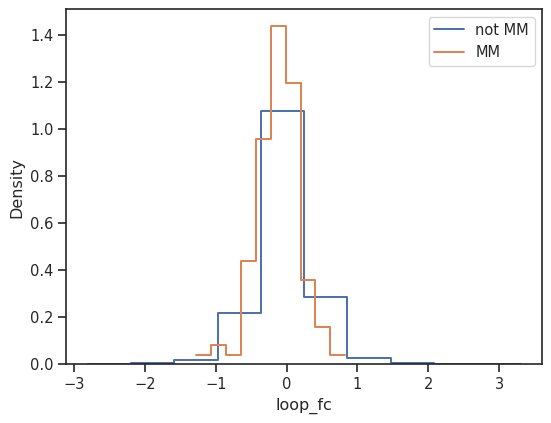

In [108]:
sns.histplot(np.log2(cc2['loop_fc'].fillna(np.nan).dropna()), stat='density', bins=10, fill=False, element='step', label='not MM')
sns.histplot(np.log2(cc['loop_fc'].fillna(np.nan).dropna()), stat='density', bins=10, fill=False, element='step', label='MM')
plt.legend()